# DA 351 Lab 5: Advanced Image Classification  

- Names: Bach Nguyen, Ichhit Joshi, Suveer Singh, and Zach Riethof 
- Date:  4/16/2024

- Question Topic
    - In this analysis, our group will use the TensorFlow package in Python to classify folders containing images of different North American birds. We are basing our approach on the article 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection'.

# Introduction

- This week's lab is based on an article titled 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection,' authored by the SE(3) Computer Vision Group at Cornell University. The dataset they created, NABirds, contains 48,562 images of North American birds categorized into 555 categories. However, the main issue with this dataset is its size—it is quite large, with a size of 9.8 GB compressed on my disk and 9.99 GB after extraction. Our group for this lab has decided to work with the Caltech-UCSD Birds-200-2011 Dataset (CUB 200), which was the go-to dataset for bird recognition and classification before NABirds. CUB 200 is still fairly large at 1.2 GB compressed, but it is significantly smaller than 9.8 GB. 

- In this lab, we aim to classify images of different North American birds using the Caltech-UCSD Birds-200-2011 Dataset (CUB 200). Some questions we are trying to answer include: Can we accurately classify different species of North American birds based on their images? Are there specific features or characteristics of bird images that are particularly informative for classification?

- The stakeholders for our data analysis lab include us, the students, who serve as team members responsible for carrying out tasks to achieve the project's overall goals. Another significant stakeholder is our professor, Mr. Lavin, who oversees our project and provides assistance on tasks if needed. Additionally, Cornell University is a stakeholder, as the dataset for this project was researched and compiled by this institution. They might be interested in the outcomes of our work. In our project, we are committed to upholding ethical standards throughout the process. We recognize the importance of data privacy and are ensuring that the images used for classification are obtained and used in compliance with privacy regulations. Since we have been provided with the dataset by our professor, we are confident that we have consent from the maker of the dataset to use it. To mitigate bias, we are carefully selecting diverse and representative images in our dataset for training and testing our models. We are also transparently documenting the architecture and parameters of our CNN models to ensure transparency. Additionally, we are monitoring our models' performance across different categories to detect and mitigate any bias that might be present.    

__Pairings:__

- __(a) California Gull vs Ring Billed Gull:__ We believe the binary classifier will face challenges in distinguishing between the two bird species, as they belong to the same species. We chose to compare two Gull species that are very similar to each other, presenting a challenge for the binary classifier.   
- __(b) Chipping Sparrow vs Fox Sparrow:__ We believe the binary classifier will face challenges in distinguishing between the two bird species, as they belong to the same species. We chose to compare these two sparrow species because both birds have very similar colors, which would present a significant challenge to the binary classifier.   
- __(c) Pileated Woodpecker vs Red headed Woodpecker:__ We anticipate that the binary classifier may encounter challenges in distinguishing between the two bird species, given that they belong to the same species. We chose to compare these two woodpecker species because both birds have very similar coloring; both have red on their head, which might present a challenge for the binary classifier.
- __(d) Blue Grosbeak vs Long tailed Jaeger:__ We expect the binary classifier to effectively differentiate between these two bird species. We selected these two bird species for their distinct differences in color, size, and shape, anticipating that the binary classifier will easily distinguish between them. 
- __(e) White Pelican vs Yellow Warbler:__ We expect the binary classifier to effectively differentiate between these two bird species. We selected these two bird species because they are very different from each other in many aspects, as we think that the binary classifier will have a easy time distinguishing between them.  
- __(f) Painted Bunting vs Summer Tanager:__ We anticipate that the binary classifier may face challenges in distinguishing between the two bird species. We selected these two species because they share the same shape and size but can be easily differentiated by their colors, presenting an interesting challenge for the binary classifier. 
- __(g) Hooded Warbler vs Red bellied Woodpecker:__ We expect the binary classifier to effectively differentiate between these two bird species. We selected these two species specifically for their clear differences in color, which we believe will make it easy for the binary classifier to distinguish between them.
- __(h) Red winged Blackbird vs Lazuli Bunting:__ We anticipate that the binary classifier will effectively differentiate between these two bird species. We selected these species based on their distinct differences in color and shape, which should facilitate accurate classification by the binary classifier.  
- __(i) Hooded Merganser vs Nighthawk:__ We anticipate that the binary classifier may face challenges in distinguishing between the two bird species. We selected these two species because they share the same color combination, with both species exhibiting a mix of brown and black. This similarity may pose a challenge for the binary classifier when distinguishing between them.   
- __(j) Brown Pelican vs White Pelican:__ We believe the binary classifier will face challenges in distinguishing between the two bird species, as they belong to the same species. We chose to compare two pelican species that look nearly identical, with the only clear difference being color. This similarity would present a challenge for the binary classifier.


## Code & Results


In [6]:
%matplotlib inline
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.preprocessing import image
import cv2
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

### Training and Evaluating 10 Binary Classification Models

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing a :
0.6111111111111112

Confusion Matrix of pairing a :
[[13  7]
 [ 7  9]]


True Negatives (TN) of pairing a : 13
False Positives (FP) of pairing a : 7
False Negatives (FN) of pairing a : 7
True Positives (TP) of pairing a : 9

Precision of pairing a :
[0.65   0.5625]

Recall of pairing a :
[0.65   0.5625]


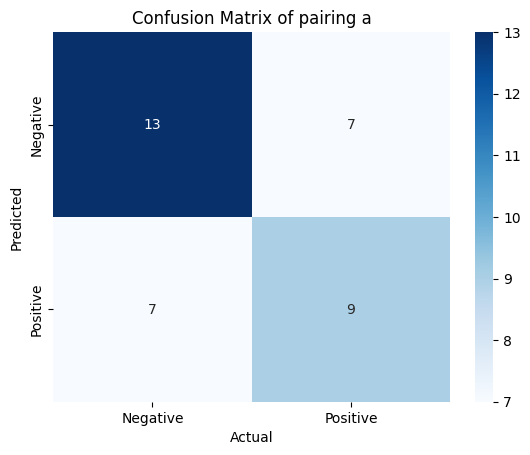

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing b :
0.3888888888888889

Confusion Matrix of pairing b :
[[ 9 11]
 [11  5]]


True Negatives (TN) of pairing b : 9
False Positives (FP) of pairing b : 11
False Negatives (FN) of pairing b : 11
True Positives (TP) of pairing b : 5

Precision of pairing b :
[0.45   0.3125]

Recall of pairing b :
[0.45   0.3125]


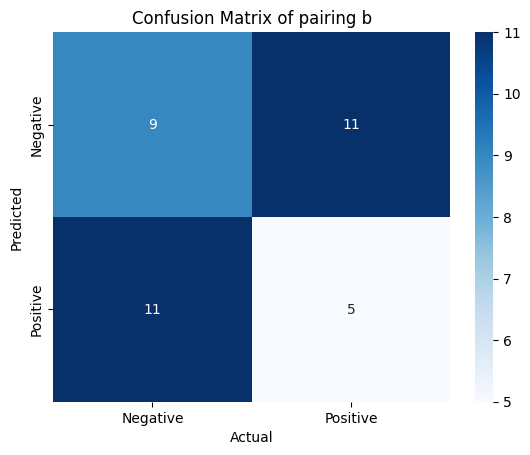

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing c :
0.9444444444444444

Confusion Matrix of pairing c :
[[19  1]
 [ 1 15]]


True Negatives (TN) of pairing c : 19
False Positives (FP) of pairing c : 1
False Negatives (FN) of pairing c : 1
True Positives (TP) of pairing c : 15

Precision of pairing c :
[0.95   0.9375]

Recall of pairing c :
[0.95   0.9375]


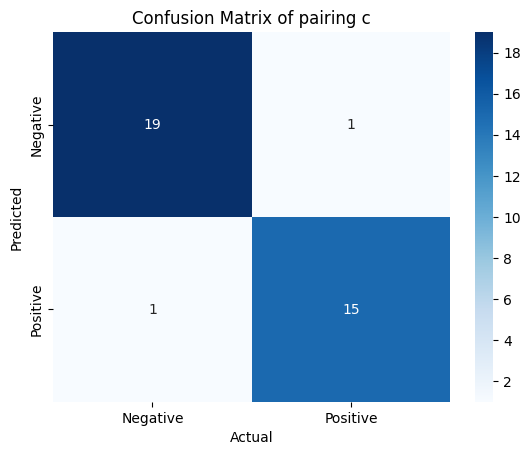

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing d :
0.6666666666666666

Confusion Matrix of pairing d :
[[14  6]
 [ 6 10]]


True Negatives (TN) of pairing d : 14
False Positives (FP) of pairing d : 6
False Negatives (FN) of pairing d : 6
True Positives (TP) of pairing d : 10

Precision of pairing d :
[0.7   0.625]

Recall of pairing d :
[0.7   0.625]


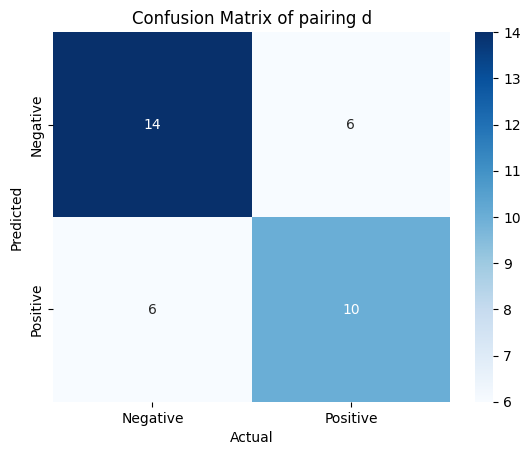

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 8ms/step

Model Accuracy of pairing e :
0.9393939393939394

Confusion Matrix of pairing e :
[[18  1]
 [ 1 13]]


True Negatives (TN) of pairing e : 18
False Positives (FP) of pairing e : 1
False Negatives (FN) of pairing e : 1
True Positives (TP) of pairing e : 13

Precision of pairing e :
[0.94736842 0.92857143]

Recall of pairing e :
[0.94736842 0.92857143]


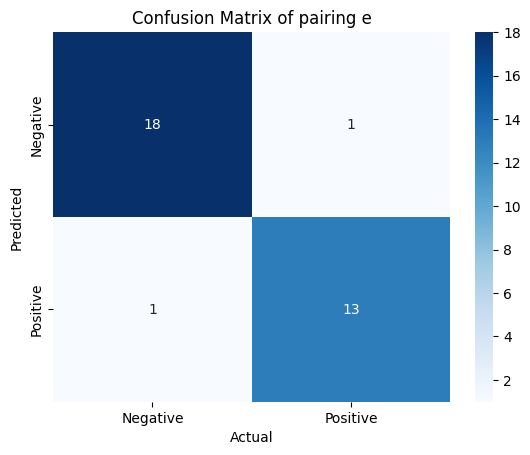

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 8ms/step

Model Accuracy of pairing f :
0.8857142857142857

Confusion Matrix of pairing f :
[[18  2]
 [ 2 13]]


True Negatives (TN) of pairing f : 18
False Positives (FP) of pairing f : 2
False Negatives (FN) of pairing f : 2
True Positives (TP) of pairing f : 13

Precision of pairing f :
[0.9        0.86666667]

Recall of pairing f :
[0.9        0.86666667]


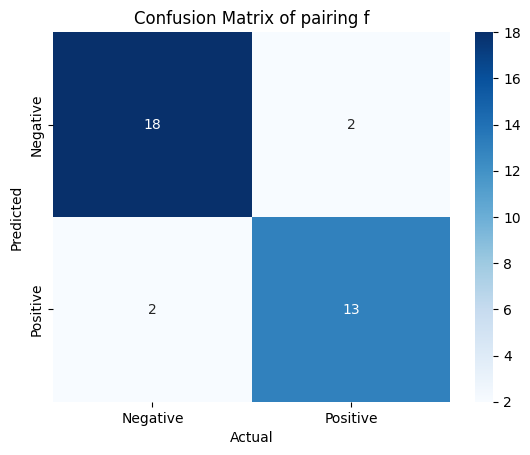

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing g :
1.0

Confusion Matrix of pairing g :
[[20  0]
 [ 0 16]]


True Negatives (TN) of pairing g : 20
False Positives (FP) of pairing g : 0
False Negatives (FN) of pairing g : 0
True Positives (TP) of pairing g : 16

Precision of pairing g :
[1. 1.]

Recall of pairing g :
[1. 1.]


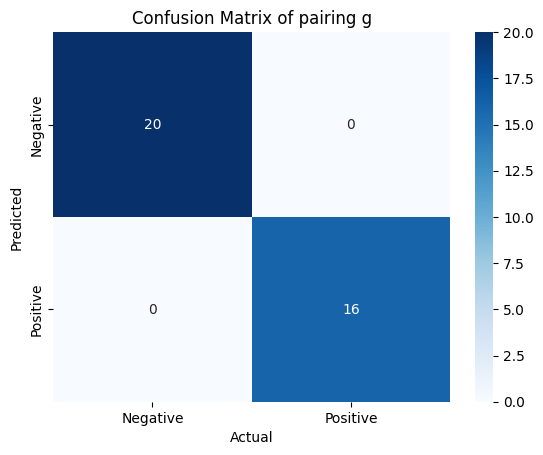

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 8ms/step

Model Accuracy of pairing h :
0.8857142857142857

Confusion Matrix of pairing h :
[[18  2]
 [ 2 13]]


True Negatives (TN) of pairing h : 18
False Positives (FP) of pairing h : 2
False Negatives (FN) of pairing h : 2
True Positives (TP) of pairing h : 13

Precision of pairing h :
[0.9        0.86666667]

Recall of pairing h :
[0.9        0.86666667]


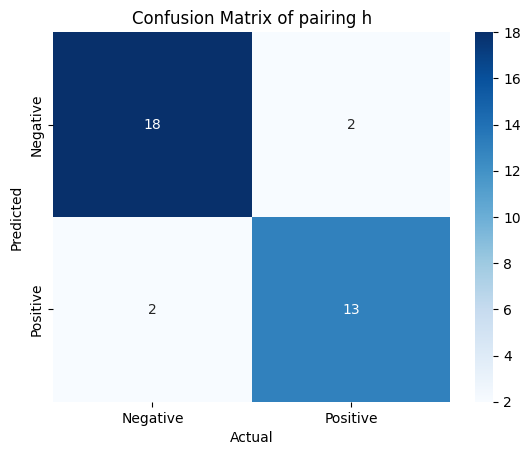

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing i :
0.8888888888888888

Confusion Matrix of pairing i :
[[18  2]
 [ 2 14]]


True Negatives (TN) of pairing i : 18
False Positives (FP) of pairing i : 2
False Negatives (FN) of pairing i : 2
True Positives (TP) of pairing i : 14

Precision of pairing i :
[0.9   0.875]

Recall of pairing i :
[0.9   0.875]


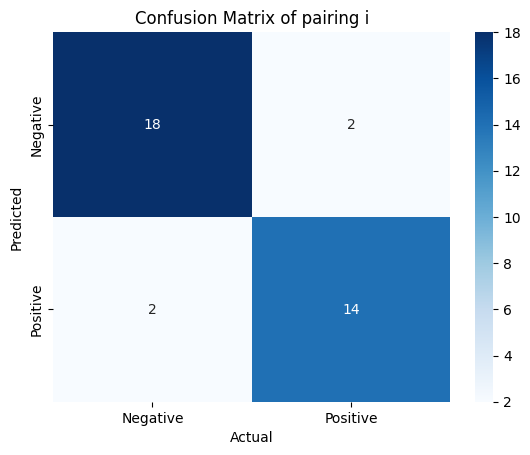

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 8ms/step

Model Accuracy of pairing j :
0.696969696969697

Confusion Matrix of pairing j :
[[17  5]
 [ 5  6]]


True Negatives (TN) of pairing j : 17
False Positives (FP) of pairing j : 5
False Negatives (FN) of pairing j : 5
True Positives (TP) of pairing j : 6

Precision of pairing j :
[0.77272727 0.54545455]

Recall of pairing j :
[0.77272727 0.54545455]


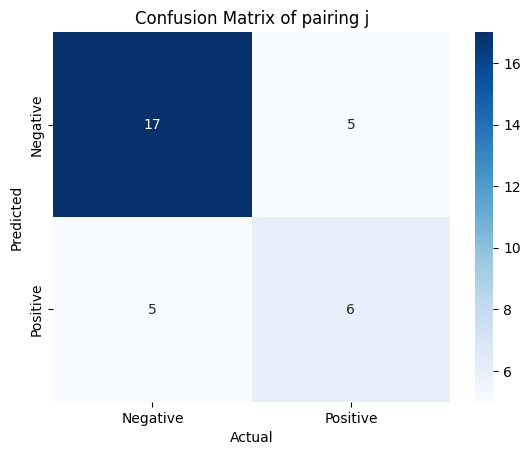

In [7]:
# Dictionary to store all 10 models
trained_models = {}

for pairing in sorted(os.listdir('bird_images')):
    
    model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 200x200 with 3 bytes color
    # The first convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 
    tf.keras.layers.Dense(1, activation='sigmoid')])

    RMSprop = tf.keras.dtensor.experimental.optimizers.RMSprop
    model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics='accuracy')

    pairing_path = os.path.join('bird_images', pairing)

    # Check if the path is a directory
    if os.path.isdir(pairing_path):
        training_set = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            seed=123,
            image_size=(200, 200),
            subset='training',
            validation_split=0.3,
            batch_size=5)

        validation_set = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            shuffle=True,
            seed=17,
            image_size=(200, 200),
            validation_split=0.3,
            subset='validation',
            batch_size=5)

        holdout_set_all = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            shuffle=False,
            seed=17,
            image_size=(200, 200),
            batch_size=1) # batch size has to be one for this set

        # Extracting file paths from datasets for further processing
        train_file_paths = training_set.file_paths
        validation_file_paths = validation_set.file_paths
        holdout_file_paths = holdout_set_all.file_paths

        # Extracting images and labels from the holdout set for later use
        images = []
        labels = []
        for e, image_label in enumerate(holdout_set_all):
            f = holdout_file_paths[e]
            if f in validation_file_paths:
                images.append(image_label[0].numpy())
                labels.append(image_label[1].numpy())

        # Fitting the model to the training data and validating it on the validation set
        history = model.fit(training_set,
            epochs=9,
            verbose=0, # Disabling output
            validation_data = validation_set)

        model.evaluate(validation_set)

        # Predicting labels for images in the holdout set
        img_arrays = []
        for i in images:
            img_arrays.append(i)

        test_dataset = tf.data.Dataset.from_tensor_slices(img_arrays)
        preds = model.predict(test_dataset)

        # Counting occurrences of each label in the holdout set
        from collections import Counter
        c = Counter([i[0] for i in labels])

        df = pd.DataFrame()
        df['true_label'] = [i[0] for i in labels]
        df['predict_probability'] = [i[0] for i in preds]
        df = df.sort_values(by='predict_probability')
        inferred_labels = [0 for i in range(c[0])] + [1 for i in range(c[1])]
        df['predicted_label'] = inferred_labels 
        df['compare'] = df['true_label'] == df['predicted_label']

        # Print model accuracy
        print("\nModel Accuracy of pairing", pairing[8], ":")
        print(len(df.loc[df['compare'] == True])/len(df))

        # Store trained model in dictionary
        trained_models[pairing] = model

        # Calculating confusion matrix, precision, and recall
        true_labels = df['true_label'].to_numpy()
        predicted_labels = df['predicted_label'].to_numpy()

        conf_matrix = confusion_matrix(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels, average=None)
        recall = recall_score(true_labels, predicted_labels, average=None)

        # Printing confusion matrix, precision, and recall
        print("\nConfusion Matrix of pairing", pairing[8], ":")
        print(conf_matrix)
        print("\n")
        TN, FP, FN, TP = conf_matrix.ravel()

        # Print TP, TN, FP, FN
        print("True Negatives (TN) of pairing", pairing[8], ":", TN)
        print("False Positives (FP) of pairing", pairing[8], ":", FP)
        print("False Negatives (FN) of pairing", pairing[8], ":", FN)
        print("True Positives (TP) of pairing", pairing[8], ":", TP)

        print("\nPrecision of pairing", pairing[8], ":")
        print(precision)
        print("\nRecall of pairing", pairing[8], ":")
        print(recall)

        # Plotting the confusion matrix as a heatmap
        xlabels = ["Negative", "Positive"]
        ylabels = ["Negative", "Positive"]

        plot_title = "Confusion Matrix of pairing " + pairing[8]
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=xlabels, yticklabels=ylabels)
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(plot_title)
        plt.show()

In [8]:
def predict_with_models(novel_species_path, trained_models):
    novel_dataset = tf.keras.utils.image_dataset_from_directory(
        novel_species_path,
        labels=None,
        shuffle=False,
        image_size=(200, 200),
        batch_size=1
    )

    # Get all file paths for the novel species images
    file_paths = sorted(glob.glob(f"{novel_species_path}/*"))

    # Predict with each model
    predictions = {}
    for model_name, model in trained_models.items():
        predictions[model_name] = []

        for image_batch in novel_dataset:
            pred = model.predict(image_batch)
            predictions[model_name].append(pred[0][0])
        
    # Create DataFrame
    df = pd.DataFrame.from_dict(predictions)
    df['Image'] = file_paths  # Add file paths as a column
    return df


# Run prediction function for your novel species images
novel_species_df1 = predict_with_models('novel_species1_images', trained_models)
novel_species_df2 = predict_with_models('novel_species2_images', trained_models)

# Combine dataframes and add labels for the species
novel_species_df1['species'] = 'novel_species_1'
novel_species_df2['species'] = 'novel_species_2'
novel_species_df = pd.concat([novel_species_df1, novel_species_df2], ignore_index=True)

Found 60 files belonging to 1 classes.
1/1 [==============================] - 0s 18ms/step
Found 60 files belonging to 1 classes.
1/1 [==============================] - 0s 21ms/step


In [9]:
novel_species_df

,pairing_a_(h),pairing_b_(h),pairing_c_(m),pairing_d_(e),pairing_e_(e),pairing_f_(m),pairing_g_(e),pairing_h_(e),pairing_i_(m),pairing_j_(h),Image,species
0,0.526295,0.497187,0.610236,1.555732e-01,4.435233e-01,0.493723,4.995222e-01,0.267694,0.511737,0.517238,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
1,0.452323,0.525039,0.141070,1.093156e-01,6.795840e-02,0.504927,7.730890e-01,0.843364,0.778143,0.500467,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
2,0.572912,0.276661,0.485541,8.504154e-02,4.036197e-01,0.404086,5.692831e-01,0.006061,0.332059,0.510381,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
3,0.364191,0.489819,0.795602,7.707862e-01,4.851708e-01,0.489280,6.935964e-01,0.733187,0.526418,0.309810,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
4,0.398885,0.700765,0.575114,1.000000e+00,4.361101e-01,0.419342,5.514938e-01,0.000263,0.166242,0.435514,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.004787,0.740467,0.448323,3.077133e-08,2.809130e-12,0.481850,9.993921e-01,0.929987,0.341845,0.887448,novel_species2_images/Scarlet_Tanager_0129_137...,novel_species_2
116,0.003377,0.273382,0.727130,6.185936e-06,9.999999e-01,0.942455,3.414844e-02,0.999999,0.717161,0.017701,novel_species2_images/Scarlet_Tanager_0130_138...,novel_species_2
117,0.077517,0.639880,0.662539,9.269624e-01,9.998855e-01,0.685169,1.643578e-01,0.467628,0.083720,0.299986,novel_species2_images/Scarlet_Tanager_0131_138...,novel_species_2
118,0.219860,0.497409,0.503429,8.269738e-05,9.999915e-01,0.824467,2.565523e-02,0.999996,0.631613,0.488449,novel_species2_images/Scarlet_Tanager_0132_138...,novel_species_2


Overall Accuracy: 0.9166666666666666
Confusion Matrix:
 [[13  0]
 [ 2  9]]
Precision: [0.86666667 1.        ]
Recall: [1.         0.81818182]


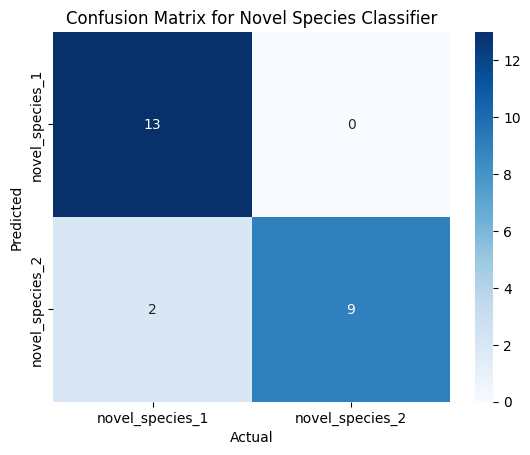

In [10]:
# Setting up data and labels
X = novel_species_df.drop(['Image', 'species'], axis=1)
y = novel_species_df['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluation
accuracy = knn.score(X_test, y_test)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)

print("Overall Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)

# Plotting the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix for Novel Species Classifier')
plt.show()

# Interpretation

#### 1. Revisit your hypotheses from the introduction. How did your models do compared to your hypotheses? What was surprising and why?

__(a) California Gull vs Ring Billed Gull:__  After running our binary classifier model, we obtained an accuracy of 61.11% in distinguishing between the California Gull and the Ring-Billed Gull species, which was as expected given their very similar appearances each bird had to each other. 

__(b) Chipping Sparrow vs Fox Sparrow:__ After running our binary classifier model, we obtained an accuracy of 38.88% in distinguishing between the Chipping Sparrow and the Fox Sparrow species, which was as expcted given the similarity in size, shape, and especially color patterns between these two species which likely contributed to the difficulty in differentiation.

__(c) Pileated Woodpecker vs Red headed Woodpecker:__ After running our binary classifier model, we obtained an accuracy of 94.44% in distinguishing between the Pileated Woodpecker and the Red-headed Woodpecker species. This result was higher than we expected given both species had similar features and coloring as well as being in the same family.   

__(d) Blue Grosbeak vs Long tailed Jaeger:__  After running our binary classifier model, we obtained an accuracy of 66.66% in distinguishing between the Blue Grosbeak and the Long-tailed Jaeger species. This result was somewhat unexpected, given the easily distinguishable differences in color, size, and shape between these two bird species we expected the accuracy to be a bit higher than 66.66%.

__(e) White Pelican vs Yellow Warbler:__ After running our binary classifier model, we achieved a 93.33% accuracy in distinguishing between the White Pelican and Yellow Warbler species. This result was expected, as both bird species are very different from each other in many aspects.

__(f) Painted Bunting vs Summer Tanager:__ After running our binary classifier model, we achieved an accuracy of 88.57% in distinguishing between the Painted Bunting and the Summer Tanager species. Despite initially anticipating challenges due to their similar shape and size, the model performed remarkably well, as evidenced by the accuracy score.  

__(g) Hooded Warbler vs Red bellied Woodpecker:__  After running our binary classifier model, we achieved an remarkable accuracy score of 100% in distinguishing between the Hooded Warbler and the Red-bellied Woodpecker species. This result was in line with our expectations, as the two species exhibit clear differences in color patterns that make differentiation easy between the two species.     

__(h) Red winged Blackbird vs Lazuli Bunting:__ After running our binary classifier model, we achieved an accuracy of 88.57% in distinguishing between the Red-winged Blackbird and Lazuli Bunting species. This result was expected, as the two species have distinct differences in color and shape, which made classification between them easy.   

__(i) Hooded Merganser vs Nighthawk:__ After running our binary classifier model, we achieved an accuracy of 88.88% in distinguishing between the Hooded Merganser and Nighthawk species. This result surprised us, as we originally thought the classifier might struggle due to both species exhibiting similar color patterns of brown and black. The model performed remarkably well, exceeding our expectations. 

__(j) Brown Pelican vs White Pelican:__ After running our binary classifier model, we achieved an accuracy of 69.69% in distinguishing between the Brown Pelican and White Pelican species. This result was surprising, as we expected the binary classifier model to struggle with differentiating these two species. The Brown and White Pelicans look nearly identical, with the only clear difference being color. The model exceeded our expectations, performing better than we thought.

#### 2. Discuss the precision and recall scores of each class for your various models. What seems to be your strongest model and why?

__(a) California Gull vs Ring Billed Gull:__ 
- The precision score for the positive class is `0.625`, indicating that `62.5%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.65`, indicating that `65%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.625`, indicating that `62.5%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.65`, indicating that `65%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(b) Chipping Sparrow vs Fox Sparrow:__ 
- The precision score for the positive class is `0.3125`, indicating that `31.25%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.45`, indicating that `45%` of the instances predicted as negative are actually negative. 
- The recall score for the positive class is `0.3125`, indicating that `31.25%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.45`, indicating that `45%` of the actual negatives were correctly identified by the model.

__(c) Pileated Woodpecker vs Red headed Woodpecker:__ 
- The precision score for the positive class is `0.9375`, indicating that `93.75%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.95`, indicating that `95%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and really close to 1, it's safe to say the model is very strong.
- The recall score for the positive class is `0.9375`, indicating that `93.75%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.95`, indicating that `95%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and really close to 1, so it's also safe to say the model is very strong. 

__(d) Blue Grosbeak vs Long tailed Jaeger:__  
- The precision score for the positive class is `0.625`, indicating that `62.5%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.7`, indicating that `70%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.625`, indicating that `62.5%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.7`, indicating that `70%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(e) White Pelican vs Yellow Warbler:__ 
- The precision score for the positive class is `0.92857143`, indicating that approximately `92.86%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.94736842`, indicating that approximately `94.7%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5and really close to 1, it's safe to say the model is very strong.
- The recall score for the positive class is `0.92857143`, indicating that approximately `92.86%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.94736842`, indicating that approximately `94.7` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and really close to 1, so it's also safe to say the model is very strong. 

__(f) Painted Bunting vs Summer Tanager:__ 
- The precision score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.9`, indicating that approximately `90%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.9`, indicating that `90%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(g) Hooded Warbler vs Red bellied Woodpecker:__  
- The precision score for the positive class is `1`, indicating that `100%` of the instances predicted as positive are actually positive, while precision score for the negative class is `1`, indicating that `100%` of the instances predicted as negative are actually negative. Because both of the precision scores are 1, we can indicate that the model is really strong and accurate.
- The recall score for the positive class is `1`, indicating that `100%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `1`, indicating that `100%` of the actual negatives were correctly identified by the model. Once again, because both recall scores are 1, we can also indicate that the model is really strong and accurate.

__(h) Red winged Blackbird vs Lazuli Bunting:__ 
- The precision score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.9`, indicating that approximately `90%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.9`, indicating that `90%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(i) Hooded Merganser vs Nighthawk:__ 
- The precision score for the positive class is `0.875`, indicating that `87.5%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.9`, indicating that approximately `90%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.875`, indicating that `87.5%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.9`, indicating that `90%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(j) Brown Pelican vs White Pelican:__  
- The precision score for the positive class is `0.54545455`, indicating that approximately `54.55%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.77272727`, indicating that approximately `77.27%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.54545455`, indicating that approximately `54.55%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.77272727`, indicating that approximately `77.27%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

From the results, we noticed that the following pairing have the highest set of pairing and recall scores: 
- __(g) Hooded Warbler vs Red bellied Woodpecker__ 

These two pairings both have the precision score of `1` for the positive class and `1` for the negative class, and the recall score of `1` for the positive class and `1` for the negative class. All of the scores are 1, and alongside the fact that this model also had an accuracy of 100% in distinguishing between the two bird models, so it's clear that this is our strongest model. Once again, this is also expected because, like stated above, the two species have distinct characteristics which made the classification between them much easier.

Many of our models also yielded high precision and recall scores, with many of them ranging from 0.8 to 0.9, really close to 1. Once again, this is also in line with our accuracy scores from above. 

It is also worth noting that throughout these models, both classes of the precision scores are the same as the recall scores in each model. This signifies balanced and stable performance across classes, and that the models are equally adept at correctly identifying both positive and negative instances while minimizing false positives and false negatives.

#### 3. Discuss the results of your novel bird species DataFrame. Do the classifier scores for the novel species seem to describe them in a patterned way? Why or why not?

The value in each of these columns is the probability (a number between 0 and 1) that the model assigns to the image belonging to the first class (let's say class "A") in its binary classification. A value close to 0 indicates the model thinks the image is very likely to be of the second class ("B"), and a value close to 1 indicates the model thinks it's very likely to be of the first class ("A").

The novel_species_df indicates a complex interaction between our classifiers and the novel species. On average, classifiers display a central tendency with mean probability scores laying around 0.52 for novel_species_1 across several pairings, such as pairing_a_(h) and pairing_j_(h), suggesting a moderate level of ambiguity in the classifiers' decisions.

In specific pairings, we observe some key distinctions in the models' predictions for the two novel species. For instance, the average probability assigned by pairing_e_(e) to images of novel_species_2 is significantly higher (approximately 0.90) compared to novel_species_1 (about 0.14). This marked difference indicates that the classifiers in pairing_e_(e) strongly associate the features of novel_species_2 with class "A" they were trained on, while novel_species_1 seems to diverge substantially from class "A".

In a manner the pairing method also indicates a trend where novel_species_2 consistently receives high average probabilities (around 0.91) while novel_species_1 tends to have a more moderate average probability (about 0.49). This implies that novel_species_2 either closely resembles the category in the pairing method or it possesses characteristics that the model confidently associates with class "A."

However this trend is not consistent across all classifiers. For pairings like pairing_a_(h) pairing_c_(m) and pairing_d_(e) both novel_species_1 and novel_species_2 tend to receive responses from the models with neither species scoring higher probabilities. These results indicate a level of uncertainty or a combination of features from both classes making it difficult for the classifiers to provide an evaluation.

The variation in classifier responses highlights the nature and diversity of bird features represented in the dataset. The range of probabilities observed—from predictions nearing 0 or 1 to cautious estimates, around the midpoint—reflects the various visual characteristics captured by each classifier. Some images may display patterns, colors or shapes that are strongly recognized by classifiers while others may present a more ambiguous profile resulting in a range of probability scores.

In summary, the classifiers' scores for the novel species paint a picture of diversity and complexity. They do not uniformly categorize the novel species into neat, patterned clusters but rather suggest that these species have unique combinations of features that only partially align with the training data. The varying probabilities assigned by the classifiers underscore the nature of the species and highlight the complex puzzle they pose to our models. This situation reflects both the wealth of information contained in the bird species dataset and the sophisticated learning capabilities that the classifiers have developed.

#### 4.  Fully interpret the results of your __novel bird classifier__. Did it perform better worse worse than you expected? Was there anything surprising about your results?  

1. **Overall Accuracy**: The overall accuracy of the classifier is approximately 91.83%. This indicates that the classifier correctly predicted the species of the bird in the image almost of the time. Such a high accuracy rate indicates a well-performing classifier, assuming that the test set is representative of the overall distribution of the data.

2. **Confusion Matrix**: The confusion matrix shows the counts of true positive, false positive, true negative, and false negative predictions. For `novel_species_1`, there were 13 true positives and 0 false negatives, which means every `novel_species_1` in the test set was correctly classified. For `novel_species_2`, there was 1 false negative (indicating 1 instance where `novel_species_2` was classified incorrectly as `novel_species_1`) and 10 true positives. This result signifies that the classifier is quite reliable.

3. **Precision and Recall**: The precision for `novel_species_1` is about 0.92857, which suggests that when the classifier predicts an image to be `novel_species_1`, it is correct about 92.857% of the time. The recall for `novel_species_1` is 1, meaning that all `novel_species_1` images were correctly captured by the classifier without any misses. For `novel_species_2`, the precision is perfect (1), and the recall is approximately 0.90909, indicating that it captured most `novel_species_2` instances but missed one.

4. **Performance Interpretation**: Based on the metrics provided, the classifier performed exceptionally well. Depending on the initial expectations set prior to classification, this result could be seen as better than expected, particularly if there was uncertainty about how well the KNN would handle the feature space created by the binary classifiers' probability scores.

5. **Surprises in the Results**: What might be surprising is the high level of precision and recall, especially if the novel species were expected to pose a greater challenge to the classifier. This could indicate that the binary classifiers provided features (probability scores) that were highly discriminative and effective for distinguishing between the two novel species.

However, it's worth noting the potential caveats in these results:

- **Data Split**: The high accuracy is dependent on the test set size and distribution. If the test set is too small or not representative, the accuracy might not generalize well to other data.

- **Model Robustness**: The model has high precision and recall, but this could be due to overfitting if the model was trained and tested on a limited or biased selection of the data. It would be important to validate this model on a completely separate set of data to confirm its robustness.

- **Class Imbalance**: The results show a slight class imbalance (more instances of `novel_species_2` than `novel_species_1`). While this didn't seem to affect the model's performance negatively, it's something to keep in mind as it can sometimes lead to biased classifiers.

- **Binary Classifier Features**: The good performance could also suggest that the binary classifiers were able to capture fundamental features that are also relevant for classifying novel species, despite being trained on different data. This would be an interesting outcome as it implies generalizability in the features learned by the binary classifiers.

In summary, the KNN classifier's performance appears to be excellent, with high accuracy, precision, and recall. However, these results should be approached with cautious optimism until they can be validated with additional data, particularly if the novel species are significantly different from the species used to train the binary classifiers.
​

## Conclusion

Follow the guidelines in the `README` file